In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
rf_model = joblib.load(
    "../models/random_forest_model.pkl"
)

print("Random Forest model loaded successfully")

Random Forest model loaded successfully


In [3]:
master_df = pd.read_csv(
    "../data/processed/featured_dataset.csv"
)

master_df['DATE_TIME'] = pd.to_datetime(
    master_df['DATE_TIME']
)

display(master_df.head())

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY,MONTH,DAY_OF_WEEK,WEEK_OF_YEAR,IS_PEAK_HOUR,TEMP_DIFFERENCE,IRRADIATION_EFFICIENCY,PREVIOUS_AC_POWER,ROLLING_MEAN_AC_POWER
0,2020-05-15,4136001,LYwnQax7tkwH5Cb,0.0,0.0,1872.500000,1.794959e+09,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
1,2020-05-15,4136001,LlT2YUhhzqhg5Sw,0.0,0.0,1094.357143,2.825928e+08,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
2,2020-05-15,4136001,Mx2yZCDsyf6DPfv,0.0,0.0,5692.200000,2.453646e+06,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
3,2020-05-15,4136001,NgDl19wMapZy17u,0.0,0.0,1866.200000,1.115126e+08,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
4,2020-05-15,4136001,PeE6FRyGXUgsRhN,0.0,0.0,651.200000,1.348351e+09,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0


In [9]:
future_df = master_df[
    master_df['IRRADIATION'] > 0.2
].tail(500).copy()

display(future_df.head())

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY,MONTH,DAY_OF_WEEK,WEEK_OF_YEAR,IS_PEAK_HOUR,TEMP_DIFFERENCE,IRRADIATION_EFFICIENCY,PREVIOUS_AC_POWER,ROLLING_MEAN_AC_POWER
134517,2020-06-17 12:45:00,4135001,zBIq5rxdHJRwDNY,10051.000000,982.125000,3622.750000,6581174.750,29.028007,47.839138,0.700175,12,17,6,2,25,1,18.811131,1402.484941,1003.014286,978.584524
134518,2020-06-17 12:45:00,4135001,VHMLBKoKgIrUVDU,10792.571430,1054.214286,3704.285714,7453905.286,29.028007,47.839138,0.700175,12,17,6,2,25,1,18.811131,1505.429208,982.125000,1013.117857
134519,2020-06-17 12:45:00,4135001,WRmjgnKYAwPKWDb,9772.142857,955.571429,3671.285714,7271250.286,29.028007,47.839138,0.700175,12,17,6,2,25,1,18.811131,1364.566159,1054.214286,997.303572
134520,2020-06-17 12:45:00,4135001,YxYtjZvoooNbGkE,10917.571430,1066.057143,3650.857143,7423206.857,29.028007,47.839138,0.700175,12,17,6,2,25,1,18.811131,1522.340934,955.571429,1025.280953
134521,2020-06-17 12:45:00,4135001,ZnxXDlPa8U1GXgE,10239.285710,1000.642857,3660.000000,6768468.000,29.028007,47.839138,0.700175,12,17,6,2,25,1,18.811131,1428.928638,1066.057143,1007.423810


In [10]:
future_features = future_df.drop(
    columns=[
        'DATE_TIME',
        'SOURCE_KEY',
        'AC_POWER',
        'DC_POWER'
    ]
)

actual_values = future_df['AC_POWER']

print("Future features prepared")

Future features prepared


In [11]:
future_predictions = rf_model.predict(
    future_features
)

print("Forecasting completed")

Forecasting completed


In [12]:
forecast_results = pd.DataFrame({

    'DATE_TIME': future_df['DATE_TIME'],

    'Actual_AC_POWER': actual_values,

    'Predicted_AC_POWER': future_predictions
})

display(forecast_results.head())

,DATE_TIME,Actual_AC_POWER,Predicted_AC_POWER
134517,2020-06-17 12:45:00,982.125000,977.433569
134518,2020-06-17 12:45:00,1054.214286,1034.828395
134519,2020-06-17 12:45:00,955.571429,971.516414
134520,2020-06-17 12:45:00,1066.057143,1037.970086
134521,2020-06-17 12:45:00,1000.642857,988.229264


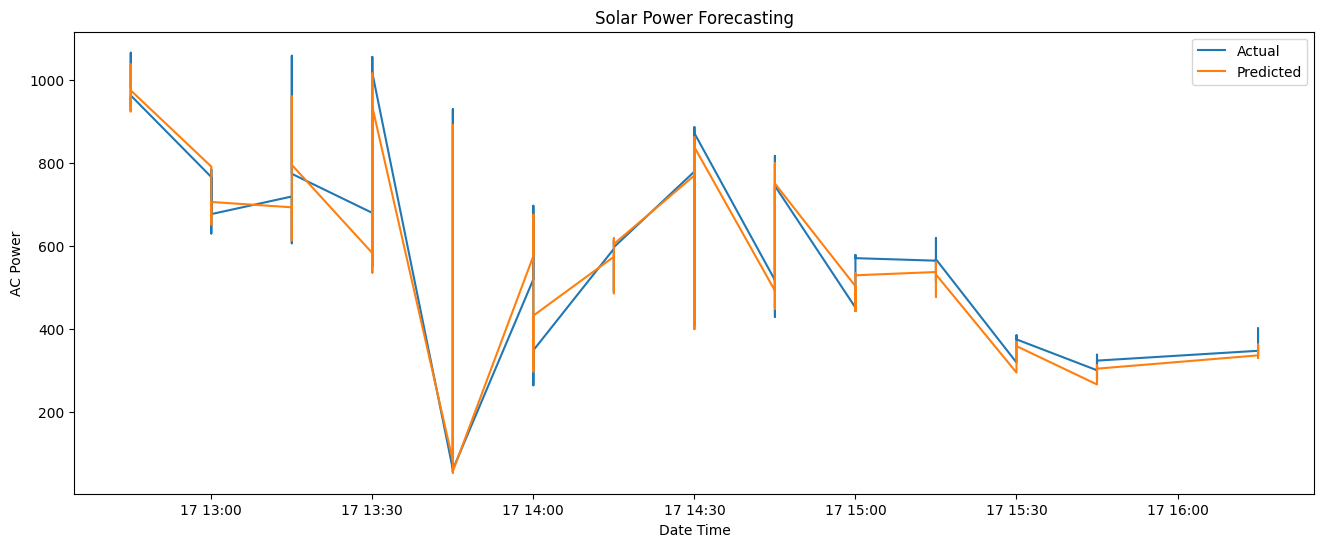

In [13]:
plt.figure(figsize=(16,6))

plt.plot(
    forecast_results['DATE_TIME'],
    forecast_results['Actual_AC_POWER'],
    label='Actual'
)

plt.plot(
    forecast_results['DATE_TIME'],
    forecast_results['Predicted_AC_POWER'],
    label='Predicted'
)

plt.title("Solar Power Forecasting")

plt.xlabel("Date Time")

plt.ylabel("AC Power")

plt.legend()

plt.show()

In [14]:
sample_future_csv = master_df[
    master_df['IRRADIATION'] > 0.2
].tail(200)

sample_future_csv.to_csv(
    "../outputs/sample_future_weather.csv",
    index=False
)

print("Sample CSV created successfully")

Sample CSV created successfully
